# Incremental Sequential Shape Classifier: Building Complex Shapes with Polygon Blocks

**Build complex 2D shapes step by step — one polygon block at a time.**

---

## 📚 Table of Contents

1. [📋 Abstract](#1-abstract)
2. [🛠️ Setup & Configuration](#2-setup--configuration)
3. [🎲 Data Generation](#3-data-generation)
4. [📈 Visualization Tools](#4-visualization-tools)
5. [⚙️ Geometric Weight Initialization](#5-geometric-weight-initialization)
6. [🔍 Cluster Detection](#6-cluster-detection)
7. [🏗️ Polygon Layer Architecture](#7-polygon-layer-architecture)
8. [🧩 Model Assembly](#8-model-assembly)
9. [🚀 Main Training Algorithm](#9-main-training-algorithm)
10. [🎯 Live Examples and Results](#10-live-examples-and-results)
11. [🧭 Conclusion & What's Next](#11-conclusion--whats-next)

---

## 1. Abstract

This notebook demonstrates an **incremental learning** approach for classifying non‑convex/holed 2‑D shapes using neural networks.  
Instead of learning shape boundaries from scratch with random weights, our method builds up complex regions by **sequentially** adding **polygon blocks** that target misclassified areas.
Each block acts like a geometric region (e.g., a triangle or quadrilateral) that can either _**add**_ or _**subtract**_ areas from the decision boundary.

### 🎬 Demo
Quick demo on S-shape and five-pointed star: 

![demo on S-shape and 5-pointed star](inc_seq_assets/animated_SShape_5Star_480px.gif)


👉 [Watch the full demo on YouTube](https://youtu.be/uYuoBcMm8dE)

---

### 📊 Example Results Preview

**L-Shape:**
<div align="center">
  <img src="https://raw.githubusercontent.com/Dani-Luk/kaggle-wrapping-convex-shape-classifier/main/inc_seq_assets/inc_seq_L1.png" height="230px" style="display:inline-block; margin:5px;">
  <img src="https://raw.githubusercontent.com/Dani-Luk/kaggle-wrapping-convex-shape-classifier/main/inc_seq_assets/inc_seq_L2.png" height="230px" style="display:inline-block; margin:5px;">
  <img src="https://raw.githubusercontent.com/Dani-Luk/kaggle-wrapping-convex-shape-classifier/main/inc_seq_assets/inc_seq_L3.png" height="230px" style="display:inline-block; margin:5px;">
  <img src="https://raw.githubusercontent.com/Dani-Luk/kaggle-wrapping-convex-shape-classifier/main/inc_seq_assets/inc_seq_L6.png" height="230px" style="display:inline-block; margin:5px;">
</div>


---

**S-Shape rotated:**
<div align="center">
  <img src="https://raw.githubusercontent.com/Dani-Luk/kaggle-wrapping-convex-shape-classifier/main/inc_seq_assets/inc_seq_SR_01.png" height="230px" style="display:inline-block; margin:5px;">
  <img src="https://raw.githubusercontent.com/Dani-Luk/kaggle-wrapping-convex-shape-classifier/main/inc_seq_assets/inc_seq_SR_02.png" height="230px" style="display:inline-block; margin:5px;">
  <img src="https://raw.githubusercontent.com/Dani-Luk/kaggle-wrapping-convex-shape-classifier/main/inc_seq_assets/inc_seq_SR_03.png" height="230px" style="display:inline-block; margin:5px;">
  <img src="https://raw.githubusercontent.com/Dani-Luk/kaggle-wrapping-convex-shape-classifier/main/inc_seq_assets/inc_seq_SR_04.png" height="230px" style="display:inline-block; margin:5px;">
  <img src="https://raw.githubusercontent.com/Dani-Luk/kaggle-wrapping-convex-shape-classifier/main/inc_seq_assets/inc_seq_SR_05.png" height="230px" style="display:inline-block; margin:5px;">
  <img src="https://raw.githubusercontent.com/Dani-Luk/kaggle-wrapping-convex-shape-classifier/main/inc_seq_assets/inc_seq_SR_12.png" height="230px" style="display:inline-block; margin:5px;">
</div>

---

**Triangle-with-hole:**
<div align="center">
  <img src="https://raw.githubusercontent.com/Dani-Luk/kaggle-wrapping-convex-shape-classifier/main/inc_seq_assets/inc_seq_TH1.png" height="230px" style="display:inline-block; margin:5px;">
  <img src="https://raw.githubusercontent.com/Dani-Luk/kaggle-wrapping-convex-shape-classifier/main/inc_seq_assets/inc_seq_TH2.png" height="230px" style="display:inline-block; margin:5px;">
  <img src="https://raw.githubusercontent.com/Dani-Luk/kaggle-wrapping-convex-shape-classifier/main/inc_seq_assets/inc_seq_TH3.png" height="230px" style="display:inline-block; margin:5px;">
  <img src="https://raw.githubusercontent.com/Dani-Luk/kaggle-wrapping-convex-shape-classifier/main/inc_seq_assets/inc_seq_TH9.png" height="230px" style="display:inline-block; margin:5px;">
</div>

---

**Figure-8 shape:**
<div align="center">
  <img src="https://raw.githubusercontent.com/Dani-Luk/kaggle-wrapping-convex-shape-classifier/main/inc_seq_assets/inc_seq_8Figure_01.png" height="230px" style="display:inline-block; margin:5px;">
  <img src="https://raw.githubusercontent.com/Dani-Luk/kaggle-wrapping-convex-shape-classifier/main/inc_seq_assets/inc_seq_8Figure_02.png" height="230px" style="display:inline-block; margin:5px;">
  <img src="https://raw.githubusercontent.com/Dani-Luk/kaggle-wrapping-convex-shape-classifier/main/inc_seq_assets/inc_seq_8Figure_03.png" height="230px" style="display:inline-block; margin:5px;">
  <img src="https://raw.githubusercontent.com/Dani-Luk/kaggle-wrapping-convex-shape-classifier/main/inc_seq_assets/inc_seq_8Figure_05.png" height="230px" style="display:inline-block; margin:5px;">
  <img src="https://raw.githubusercontent.com/Dani-Luk/kaggle-wrapping-convex-shape-classifier/main/inc_seq_assets/inc_seq_8Figure_09.png" height="230px" style="display:inline-block; margin:5px;">
  <img src="https://raw.githubusercontent.com/Dani-Luk/kaggle-wrapping-convex-shape-classifier/main/inc_seq_assets/inc_seq_8Figure_15.png" height="230px" style="display:inline-block; margin:5px;">
</div>


_Feel free to run the cells at the end of this notebook and adjust the parameters (e.g., number of sides per block) to explore how the model evolves and behaves on different shapes._

### 🧩 Key Features:
- **Incremental Block Learning** – dynamically adds new polygon blocks to correct misclassified regions.
- **Cluster Detection** – automatically identifies false-positive and false-negative clusters using DBSCAN.
- **Geometric Initialization** – estimates the center and radius of each new polygon from the cluster’s min/max bounds.
- **Rich Visualizations** – provides clear insights into block hyperplanes and resulting decision boundaries.

### 🏗️ Architecture Overview

```
 Input(x,y) → --- (shared to all blocks) ---
               ↓            ↓            ↓
            [Block₁] → ( [Block₂] → ( [Block₃] → (...) ) ) → Sigmoid → Output
               ↓            ↓            ↓
           α₁·f₁(x,y) + α₂·f₂(x,y) + α₃·f₃(x,y) + ...
                                
```

Each **PolygonBlock** contains:
- Dense layer with `n_sides` neurons (hyperplanes intersection = polygon interior)
- ReLU activation + Product operation (AND logic)
- Trainable parameters: sharpness (K), bias (b), alpha (α)
- **Alpha controls contribution**: +α adds regions, -α subtracts regions

### 🔁Workflow:
1. Initialize the first block as an n-sided regular polygon, with α = +1, covering the entire shape.
2. Train initial model
3. Find largest error cluster (FP or FN)
4. Add new block initialized around the cluster
5. Train with boosted sample weights on cluster points
6. Fine-tune all layers
7. Repeat (from step 3) until no significant clusters remain or **max_blocks** reached





## 2. Setup & Configuration

Prepare the environment, import dependencies, and set parameters for the incremental shape classifier.

### Environment Setup

In [3]:
# Suppress TensorFlow warnings and info messages - MUST BE FIRST!
import os
import warnings

# Set environment variables BEFORE importing TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress all TensorFlow logging
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Disable oneDNN optimizations messages
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # Disable CUDA messages (force CPU)

# Additional warning suppression
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import random
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, Lambda, Activation, Concatenate, Add
# from tensorflow.keras.layers import Input, Concatenate, Dense
# from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt
# from IPython.display import display, update_display, clear_output

tf.get_logger().setLevel('ERROR')  # Only show TensorFlow errors

# Set matplotlib style for better visualizations
plt.style.use('default')
plt.rcParams['figure.dpi'] = 60 # 72
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 10)

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

def set_random_seed(seed: int):
    """Set random seed for reproducible results across all libraries"""
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    print(f"Random seed set to: {seed}")
    

TensorFlow version: 2.18.0
NumPy version: 1.26.0


### Training Configuration


In [4]:
# Verbosity controls
PRINT_VERBOSE = 1  # Set to 1 for detailed logs, 0 for minimal output
PLOT_VERBOSE = 0   # Set to 1 for plotting each stage, 0 to only see final plots

# Training parameters
VALIDATION_SIZE = 0.3  # Fraction of data to use as validation set

# Cluster detection parameters (DBSCAN)
CLUSTER_MIN_SAMPLES = 8  # Minimum number of points to form a cluster in DBSCAN
CLUSTER_EPS = 0.3        # Maximum distance between points to be considered in the same cluster


def print_verbose(*args, **kwargs):
    """Print message if VERBOSE is enabled"""
    if PRINT_VERBOSE:
        print(*args, **kwargs)

def print_block_alphaKb(text, layer):
    alpha = layer.alpha.numpy()
    K = layer.K.numpy()
    b = layer.b.numpy()
    print_verbose(f"{text}: {alpha=}, {K=}, {b=}")

print_verbose("✓ Configuration loaded")

✓ Configuration loaded


### Utility Functions

In [5]:
def compute_iou(y_true, y_pred_probs, threshold=0.5):
    """Compute Intersection over Union (IoU) for binary classification."""
    y_pred = (y_pred_probs > threshold).astype(int)
    intersection = np.sum((y_true == 1) & (y_pred == 1))
    union = np.sum((y_true == 1) | (y_pred == 1))
    return intersection / (union + 1e-8)


def validate_model_initialization(model):
    """
    Validate that the model initialization is correct by testing the origin.

    The origin (0,0) should be classified as inside (class=1) for proper initialization.
    """
    origin_prediction = model.predict(np.array([[0.0, 0.0]]), verbose=0)[0][0]
    
    try:
        assert origin_prediction > 0.5, f"Origin prediction should be > 0.5, got {origin_prediction:.4f}"
        print_verbose(f"✓ Model initialization checked! (origin prediction = {origin_prediction:.4f})")
        return True
    except AssertionError as e:
        print_verbose(f"✗ Model initialization failed: {e}")
        return False

print_verbose("✓ Utility functions ready")

✓ Utility functions ready


## 3. Data Generation

We need a diverse set of 2-D shapes to test our incremental learning approach.  
Our data generators produce a variety of challenging geometries — from simple convex forms to complex non-convex and holed shapes.

- **Circles / Ellipses** – test basic convex approximation
- **L-Shapes / S-Shapes** – test non-convex region handling
- **Stars** – test highly concave boundaries
- **Donuts** – test holes and exclusion regions
- **Triangle-with-hole** – test nested boundaries and shape subtraction
- **Figure-8 shapes** – test complex real-world topologies

In [6]:
def generate_disk_data(random_seed=None, n_samples=3000, radius_x=1.0, radius_y=1.0):
    """
    Generate binary classification data for ellipse/circle shapes.
    
    Args:
        n_samples: Number of random points to generate
        radius_x: Semi-axis length in x direction
        radius_y: Semi-axis length in y direction
        
    Returns:
        X: Array of 2D points
        y: Binary labels (1=inside, 0=outside)
    """
    # Set random seed
    if random_seed is None:
        random_seed = random.randint(1, 1000)
    set_random_seed(random_seed)
    
    X = np.random.uniform(-2.5, 2.5, size=(n_samples, 2))
    
    # Ellipse equation: (x/a)² + (y/b)² < 1
    inside_ellipse = (X[:, 0]**2 / radius_x**2 + X[:, 1]**2 / radius_y**2) < 1
    y = inside_ellipse.astype(np.float32)
    
    return X, y


def generate_polygon_data(random_seed=None, corners=[(0, 1.5), (-1.3, -0.75), (1.3, -0.75)], n_samples=3000 ):
    """
    Generate binary classification data for N-sided polygons using ray casting.
    Args:
        n_samples: Number of random points to generate
        corners: List of N vertices in counter-clockwise order (Default: Equilateral triangle)
            Returns:
        X: Array of 2D points
        y: Binary labels (1=inside, 0=outside)
    """
    # Set random seed
    if random_seed is None:
        random_seed = random.randint(1, 1000)
    set_random_seed(random_seed)
    
    X = np.random.uniform(-3, 3, size=(n_samples, 2))
    
    def point_in_polygon(point, polygon_corners):
        """Ray casting algorithm for point-in-polygon test"""
        x, y = point
        n = len(polygon_corners)
        inside = False
        
        p1x, p1y = polygon_corners[0]
        for i in range(1, n + 1):
            p2x, p2y = polygon_corners[i % n]
            if y > min(p1y, p2y):
                if y <= max(p1y, p2y):
                    if x <= max(p1x, p2x):
                        if p1y != p2y:
                            xinters = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
                        if p1x == p2x or x <= xinters:
                            inside = not inside
            p1x, p1y = p2x, p2y
        return inside
    
    y = np.array([point_in_polygon(point, corners) for point in X]).astype(np.float32)
    return X, y


def generate_donut_data(random_seed=None, n_samples=3000, inner_radius=1.00, outer_radius=2.40):
    """Generate donut/annulus shape data centered in origin."""
    # Set random seed
    if random_seed is None:
        random_seed = random.randint(1, 1000)
    set_random_seed(random_seed)

    X = np.random.uniform(-3, 3, (n_samples, 2))
    dist = np.sqrt((X[:,0])**2 + (X[:,1])**2)
    y = ((dist < outer_radius) & (dist > inner_radius)).astype(np.float32)
    return X, y


def generate_eight_shape_data_normalized(random_seed=None, n_samples=3000, inner_radius_1=0.11, outer_radius_1=0.25, inner_radius_2=0.14, outer_radius_2=0.28):
    """Generate figure-eight or double donut shape data."""
        # Set random seed
    if random_seed is None:
        random_seed = random.randint(1, 1000)
    set_random_seed(random_seed)
    X = np.random.uniform(0, 1, (n_samples, 2))
    cx_1, cy_1 = np.random.uniform(0.3, 0.35, 2)
    cx_2, cy_2 = np.random.uniform(0.6, 0.65, 2)
    dist_1 = np.sqrt((X[:,0]-cx_1)**2 + (X[:,1]-cy_1)**2)
    dist_2 = np.sqrt((X[:,0]-cx_2)**2 + (X[:,1]-cy_2)**2)
    y = (((dist_1 < outer_radius_1) & (dist_1 > inner_radius_1)) | ((dist_2 < outer_radius_2) & (dist_2 > inner_radius_2))).astype(np.float32)
    return X, y 


def generate_n_star_data(random_seed=None, n_samples=3000, n_corners=5, inner_radius=1.25, outer_radius=2.50):
    """Create n-pointed star shape data by defining outer and inner corners.
    Args:
        n: Number of data points
        n_corners: Number of star points
        inner_radius: Radius of inner vertices
        outer_radius: Radius of outer vertices (star tips)
    """
        # Set random seed
    if random_seed is None:
        random_seed = random.randint(1, 1000)
    set_random_seed(random_seed)
    angles = np.linspace(0, 2 * np.pi, n_corners, endpoint=False)
    # Adding some noise to make it less regular
    angles += np.random.uniform(-0.1, 0.1, size=n_corners)
    outer_corners = np.c_[np.cos(angles), np.sin(angles)] * outer_radius
    inner_corners = np.c_[np.cos(angles + np.pi / n_corners), np.sin(angles + np.pi / n_corners)] * inner_radius
    corners = []
    for i in range(n_corners):
        corners.append((outer_corners[i,0], outer_corners[i,1]))
        corners.append((inner_corners[i,0], inner_corners[i,1]))
    return generate_polygon_data(corners=corners, n_samples=n_samples, random_seed=random_seed)

print_verbose("✓ Data generation functions ready")



✓ Data generation functions ready


## 4. Visualization Tools

To better understand how the incremental approach behaves, we provide visualization utilities that display:

- **Decision boundaries** – regions where the model separates classes
- **Hyperplane lines** – edges formed by each polygon block
- **True boundaries** – ground-truth shape contours for comparison
- **Classification results** – correctly and incorrectly classified points

In [17]:
class TrueBoundaryApprox:
    """
    Creates a smooth approximation of the true shape boundary for visualization.

    This class precomputes and stores a high-resolution grid, then finds the nearest
    labeled point for each grid location to generate smooth boundary curves for future plots.
    """
        
    def __init__(self, X, y, x_range=(-3, 3), resolution=60, color='yellow', alpha=0.8):
        self.X = X
        self.y = y
        self.x_range = x_range
        self.resolution = resolution
        self.color = color
        self.alpha = alpha

        # Precompute grid and labels (expensive part)
        self._compute_grid_labels()

    def _compute_grid_labels(self):
        """Pre-compute grid labels using nearest neighbor approximation."""
        xx, yy = np.meshgrid(
            np.linspace(*self.x_range, self.resolution),
            np.linspace(*self.x_range, self.resolution)
        )
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        distances = cdist(grid_points, self.X)
        closest_indices = np.argmin(distances, axis=1)
        grid_true_labels = self.y[closest_indices].reshape(xx.shape)
        self.xx, self.yy, self.grid_true_labels = xx, yy, grid_true_labels

    def add_to_plot(self, ax):
        """Add true boundary contour to existing plot."""
        ax.contour(
            self.xx, self.yy, self.grid_true_labels,
            levels=[0.5], # Decision boundary
            colors=[self.color],
            linewidths=3,
            linestyles='--',
            alpha=self.alpha
        )

def plot_dataset_predictions_and_boundaries(model, X, y_true, ax, x_range=(-3, 3), resolution=100):
    """
    Plot dataset with model predictions and boundaries by showing correct/incorrect classifications to multiple axes
    """
    # Get model predictions (calculate once, reuse for all axes)
    y_pred = model.predict(X, verbose=0).flatten()
    pred_labels = (y_pred > 0.5).astype(int)
    
    # Create background grid for prediction visualization with configurable resolution
    xx, yy = np.meshgrid(np.linspace(*x_range, resolution), np.linspace(*x_range, resolution))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_pred = model.predict(grid_points, verbose=0).reshape(xx.shape)

    # Plot prediction background (decision regions)
    ax.contourf(xx, yy, grid_pred, levels=5, cmap="RdBu", alpha=0.6, vmin=0, vmax=1)

    # Plot decision boundary
    ax.contour(xx, yy, grid_pred, levels=[0.5], colors="black", linewidths=3, alpha=0.9)

    # Plot points with correct/incorrect markers
    for i in range(len(X)):
        is_correct = (pred_labels[i] == y_true[i])
        marker = 'o' if is_correct else 'x'
        size = 25 if is_correct else 35
        color = 'red' if pred_labels[i] == 1 else 'blue'
        alpha = 0.7 if is_correct else 0.9
        edge_width = 0.5 if is_correct else 1.2
        ax.scatter(X[i, 0], X[i, 1], c=color, marker=marker, s=size,
                   alpha=alpha, edgecolors='black', linewidth=edge_width)
# end plot_dataset_predictions_and_boundaries


def plot_layer(ax, block_layer, x_range=(-3, 3), alpha=0.8):
    """
    Plot the model weight lines(polygon lines) into ax axis, color-coded by block_layer.alpha sign:
        - Red lines: Positive alpha (additive regions)
        - Blue lines: Negative alpha (subtractive regions)
    """
    weights, biases = block_layer.poly.get_weights()
    # decide color by alpha
    alpha_val = block_layer.alpha.numpy()
    color = "red" if alpha_val >= 0 else "blue"

    for i in range(weights.shape[1]):
        w1, w2 = weights[:, i]
        bias = biases[i]
        
        if abs(w2) > 1e-8:  # Non-vertical line: w1*x + w2*y + bias = 0
            # Use two points to define the line within the x_range
            x1, x2 = x_range[0], x_range[1]
            y1 = -(w1 * x1 + bias) / w2
            y2 = -(w1 * x2 + bias) / w2
            # Use axline with two points and clip to axes limits
            ax.axline((x1, y1), (x2, y2), color=color, linewidth=1.8, alpha=alpha)
        else:  # Vertical line: x = -bias/w1
            x_line = -bias / w1
            # Only draw if within x_range
            if x_range[0] <= x_line <= x_range[1]:
                ax.axvline(x=x_line, color=color, linewidth=1.8, alpha=alpha)
    
    # Set axis limits to ensure clipping
    ax.set_xlim(x_range)
    ax.set_ylim(x_range)
    return
# end plot_layer


def plot_all_blocks(model, ax, x_range=(-3, 3)):
    """Plot all PolygonLayers in the model."""
    block_layers = [l for l in model.layers if "polygon_layer" in l.name]
    n_blocks = len(block_layers)

    for i, block in enumerate(block_layers):
        plot_layer(ax, block, x_range, alpha = 0.5 if i < n_blocks - 1 else 0.8)  # last block more opaque 


def plot_model(plot_verbose, model, X_train, y_train, X_val, y_val, title="", true_boundary_approx:TrueBoundaryApprox|None=None):
    """
    Create comprehensive training result visualization.
    - Training data points
    - True boundary approximation (if provided)
    - Model decision boundary and polygon hyperplanes regions
    - Performance metrics in title
    """    
    if plot_verbose:
        ax = plt.gca()
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)        
        plot_dataset_predictions_and_boundaries(model, X_train, y_train, ax)
        plot_all_blocks(model, ax)
        if true_boundary_approx:
            true_boundary_approx.add_to_plot(ax)
        val_iou = compute_iou(y_val, model.predict(X_val, verbose=0).flatten())
        train_iou = compute_iou(y_train, model.predict(X_train, verbose=0).flatten())
        ax.set_title(f"{title}: {train_iou=:.2%}, {val_iou=:.2%} ", fontsize=16)
        plt.show()

print_verbose("✓ Visualization functions ready")

✓ Visualization functions ready


## 5. Geometric Weight Initialization

Instead of random initialization, we use **geometric intuition** to provide the model with a strong starting point.

Each polygon block represents a set of hyperplanes. By initializing these hyperplanes to approximate a circle (an n-sided regular polygon), the model begins with a balanced and spatially uniform configuration for discovering cluster boundaries.

In [18]:
def get_polygon_circle_weights(n_sides=4, radius=2.0):
    """
    Initialize polygon layer weights to approximate a circle.
    The catches: 
        - keep left! ;) when generating the polygon so the inside and outside will be well classified  
        - choose a radius large enough to contain the shape, 
        and don't forget to leave enough points outside, to have thereby good examples outside 
        and so the model will be able to start the learning process

    This geometric initialization ensures the model starts with a reasonable
    approximation rather than random weights.
    
    Args:
        n_sides: Number of polygon sides (hyperplanes)
        radius: Initial radius of the approximated circle
        
    Returns:
        weights: Weight matrix [2, n_sides] 
        biases: Bias vector [n_sides]
    """
    assert n_sides > 2, "Number of sides must be greater than 2 anyway"
    angles = np.linspace(0, 2 * np.pi, n_sides, endpoint=False)
    
    # Each column represents a hyperplane normal vector
    # Use outward-pointing normals: for w·x + b > 0 to define "inside"
    # For circle: w·x + b = cos(θ)·x + sin(θ)·y + R = 0 is the boundary
    weights = np.stack([np.cos(angles), np.sin(angles)], axis=1).T / radius
    biases = np.ones(n_sides)  # This gives b = 1, so boundary is at radius = 1*radius = radius

    return weights, biases

def get_cluster_weights(X_cluster, cluster_type, n_sides=3):
    """
    Return weights&biases for a polygon (triangle by default) to enclose a cluster.

    Args:
        X_cluster: (N, 2) array of points in the selected cluster
        n_sides: number of polygon sides (3 for triangle)

    Returns:
        weights: (2, n_sides)
        biases: (n_sides,)
    """
    assert X_cluster.shape[1] == 2, "Cluster points must be 2D"

    # 1) Find bounding box
    x_min, y_min = np.min(X_cluster, axis=0)
    x_max, y_max = np.max(X_cluster, axis=0)

    # 2) Compute center and "radius" (half of diagonal)
    cx, cy = (x_min + x_max) / 2, (y_min + y_max) / 2

    if cluster_type == 'FN':
        # For False Negative clusters (inside points), we'll try IN-OUT(expanding) so starting from min radius = inscribed circle into the rectangle
        radius = min((x_max - x_min), (y_max - y_min)) / 2.0  # aprox inscribed circle radius
    else:
        # For False Positive clusters (outside points), we'll try OUT-IN(contracting) so starting from max radius = half diagonal of bounding box
        radius = max((x_max - x_min), (y_max - y_min)) / 2.0  # aprox circumscribed circle radius

    print_verbose(f"Estimated: cluster center(x, y) = ({cx:.2f}, {cy:.2f}), radius = {radius:.2f}")

    # 3) Reuse circle initializer with translation
    weights, biases = get_polygon_circle_weights(n_sides=n_sides, radius=radius)

    # 4) Adjust biases to shift polygon to cluster center
    # Each hyperplane is defined by w·x + b > 0 for "inside"
    # To translate: replace b with b - w·center (so w·(x-center) + b > 0 becomes w·x + (b - w·center) > 0)
    # NOTE: weights shape is (2, n_sides) → each column = normal vector

    translations = np.dot(weights.T, np.array([cx, cy]))
    biases = biases - translations  # very important: subtract the translation! because of the sign convention in get_polygon_circle_weights()

    return weights, biases

print_verbose("✓ Weight initialization functions ready")

✓ Weight initialization functions ready


## 6. Cluster Detection

The strategic placement of new blocks is guided by density-based clustering (DBSCAN), which identifies the largest false-positive or false-negative cluster to target next.

In [19]:
def find_largest_error_cluster(X, y_true, y_pred, eps=CLUSTER_EPS, min_samples=CLUSTER_MIN_SAMPLES):
    """
    Find the largest FP or FN cluster separately.

    Args:
        X: (N, 2) input points
        y_true: (N,) ground-truth labels (0/1)
        y_pred: (N,) model predictions (0-1)
        eps: DBSCAN neighborhood radius
        min_samples: DBSCAN minimum points per cluster

    Returns:
        cluster_type: "FP" or "FN"
        X_cluster: points in largest cluster
        idx_cluster: indices of points in largest cluster
    """
    # 1) Split errors
    FP_idx = np.where((y_true == 0) & (y_pred > 0.5))[0]
    FN_idx = np.where((y_true == 1) & (y_pred <= 0.5))[0]

    # Helper to run DBSCAN and find largest cluster
    def run_dbscan(indices, label):
        if len(indices) == 0:
            return None, None, None
        X_err = X[indices]
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_err)
        labels = db.labels_

        # Ignore noise points (-1)
        clusters = [np.where(labels == c)[0] for c in set(labels) if c != -1]
        if not clusters:
            return None, None, None

        # Pick largest cluster
        largest = max(clusters, key=len)
        return label, X_err[largest], indices[largest]

    # 2) Run separately for FP and FN
    cluster_fp = run_dbscan(FP_idx, "FP")
    cluster_fn = run_dbscan(FN_idx, "FN")

    # 3) Choose the larger cluster (if both exist)
    if cluster_fp[1] is None and cluster_fn[1] is None:
        return None, None, None
    if cluster_fp[1] is None: return cluster_fn
    if cluster_fn[1] is None: return cluster_fp

    return cluster_fp if len(cluster_fp[1]) >= len(cluster_fn[1]) else cluster_fn # NOTE: what about ">=" vs ">" ...?

print_verbose("✓ Cluster detection function ready")

✓ Cluster detection function ready


## 7. Polygon Layer Architecture

Our **PolygonLayer** is the building block of our entire approach. Each layer represents a single polygon that can add or subtract regions from the decision boundary.

### Mathematical Foundation:
- Each layer has `n_sides` hyperplanes: `w_i · x + b_i`
- ReLU activation: `h_i = max(0, w_i · x + b_i)`
- Product operation: `z = ∏ h_i` (AND logic - all hyperplanes must be satisfied)
- Final contribution: `α * (K * z + b)` where α controls add/subtract

In [20]:
class PolygonLayer(tf.keras.layers.Layer):
    """
    A custom Keras layer that represents a trainable polygon region.
    
    It combines:
    - Geometric initialization (smart starting weights)
    - Logical AND operation (product of ReLUs)
    - Trainable contribution (alpha parameter)
    
    Mathematical flow:
    1. Linear: s = W·x + b  (hyperplanes)
    2. ReLU: h = max(0, s)  (positive side of each hyperplane)
    3. Product: z = ∏ h     (intersection = polygon interior, because of weight initialization)
    4. Scale: output = α * (K * z + b)
    
    The alpha parameter is key:
    - α > 0: Add this region to the decision boundary
    - α < 0: Subtract this region from the decision boundary
    """

    def __init__(self, weights, biases, n_sides=3, alpha_init=1.0, name="polygon_layer", **kwargs):
        super().__init__(name=name, **kwargs)
        self.n_sides = n_sides
        self.init_weights = (weights, biases)
        self.alpha_init = alpha_init
        # define Dense as a sub-layer, Keras will manage its kernel+bias
        self.poly = Dense(self.n_sides, use_bias=True, activation=None, name=f"{name}_s")

    def build(self, input_shape):
        """Initialize all trainable parameters."""
        
        # initialize the dense layer with our geometric weights
        self.poly.build((None, 2))
        self.poly.set_weights(self.init_weights)

        # trainable sharpness parameter K (controls polygon edge steepness)
        self.K = self.add_weight(
            name="sharpness",
            shape=(),
            initializer=tf.keras.initializers.Constant(10),
            trainable=True
        )

        # trainable bias term to shift polygon contribution
        self.b = self.add_weight(
            name="bias",
            shape=(),
            initializer="zeros",
            trainable=True
        )        

        # trainable alpha (contribution weight)
        self.alpha = self.add_weight(
            name=f"alpha",
            shape=(),
            initializer=tf.keras.initializers.Constant(self.alpha_init),
            trainable=True,
            dtype=tf.float32
        )

    def call(self, inputs):
        """Forward pass through the polygon layer."""
        xy, z_old = inputs   # unpack current point and accumulated signal

        # Compute polygon/hyperplanes values
        s = self.poly(xy) # shape: (batch, n_sides)

        # Apply ReLU (only positive side of hyperplanes)
        h_in = tf.nn.relu(s)

        # Product operation (AND logic)
        # All hyperplanes must be positive for point to be inside polygon
        z_in = tf.reduce_prod(h_in, axis=-1, keepdims=True)

        # Update accumulated signal with new polygon contribution (alpha-scaled)
        return z_old + self.alpha * (self.K * z_in + self.b)

print_verbose("✓ PolygonLayer defined")

✓ PolygonLayer defined


## 8. Model Assembly

In [21]:
def build_initial_model(weights, biases, n_sides=3, alpha_init=1.0):
    """
    Build the initial model with one polygon block.
    
    The architecture is:
    - Input: 2D coordinates (x, y)
    - Accumulator: Starts at zero for each point
    - Polygon block: Adds first shape approximation (using PolygonLayer) as regular n_sides polygon with positive alpha_init
    - Sigmoid: Converts accumulated signal to probability
    
    Args:
        weights, biases: Geometric initialization for hyperplanes
        n_sides: Number of polygon sides
        alpha_init: Initial contribution weight
        
    Returns:
        Compiled Keras model ready for training
    """
        
    xy = Input(shape=(2,), name="xy")
    z0 = Lambda(lambda x: tf.zeros((tf.shape(x)[0], 1)))(xy)   # accumulator start

    block = PolygonLayer(weights, biases, n_sides=n_sides, alpha_init=alpha_init, name="polygon_layer_0")
    z1 = block([xy, z0])

    # out = Activation(lambda x: tf.sigmoid(5 * x), name="out")(z1) # NOTE: DO NOT TRY THIS + initial epochs training of 100 epochs on Holed shapes ! :D
    # out = Activation(lambda x: tf.sigmoid(10 * x), name="out")(z1)
    out = Activation(lambda x: tf.sigmoid(20 * x), name="out")(z1)
    
    model = Model(inputs=xy, outputs=out)
    model.compile(optimizer="adam", loss="mse", metrics=[tf.keras.metrics.BinaryAccuracy()])
    return model


def add_block_layer(model, weights, biases, n_sides=3, alpha_init=1.0, name=None):
    """
    Add a new polygon block to an existing model.
    
    This is where incremental learning happens! We:
    1. Freeze all existing layers (preserve learned knowledge)
    2. Extract the current accumulator (before final sigmoid)
    3. Add a new polygon block targeting specific errors
    4. Create a new model with the additional block
    
    Args:
        model: Existing trained model
        weights, biases: Initialization for new block
        n_sides: Number of sides for new polygon
        alpha_init: Initial contribution (+1 for add, -1 for subtract)
        block_name: Optional name for the new block
        
    Returns:
        New model with additional polygon block
    """    
    
    assert "polygon_layer" in model.layers[-2].name, "Last but one layer must be a PolygonLayer"

    # Freeze existing layers
    for layer in model.layers:
        layer.trainable = False

    xy = model.input
    z_old = model.layers[-2].output   # the last accumulator before sigmoid

    block_name = name or f"polygon_layer_{len([l for l in model.layers if 'polygon_layer' in l.name])}"
    block = PolygonLayer(weights, biases, n_sides=n_sides, alpha_init=alpha_init, name=block_name)
    z_new = block([xy, z_old])

    # out_new = Activation(lambda x: tf.sigmoid(20 * x), name="out")(z_new)
    # out_new = Activation(lambda x: tf.sigmoid(10 * x), name="out")(z_new)
    out_new = Activation(lambda x: tf.sigmoid(5 * x), name="out")(z_new)

    model_new = Model(inputs=xy, outputs=out_new)
    model_new.compile(optimizer="adam", loss="mse", metrics=[tf.keras.metrics.BinaryAccuracy()])
    
    return model_new

print_verbose("✓ Model building functions ready")

✓ Model building functions ready


## 9. Main Training Algorithm

In [24]:
def run_model_incremental(shape_type, X, y, 
                        max_blocks=3, n_sides=3, 
                        random_seed=None, n_samples=3000
                        ):
    """ 
    Training Workflow:
    - Train initial model.
    - Evaluate → get FP/FN clusters.
    - Call add_block_layer() 
    - Warm-up train with sample_weight on idx_clusters
    - Unfreeze & fine-tune.
    - Repeat until clusters < threshold.
    """
    # Set random seed
    if random_seed is None:
        random_seed = random.randint(1, 1000)
    set_random_seed(random_seed)
    
    print_verbose(f"{'='*60}")
    print_verbose(f"RUNNING Shape: {shape_type.upper()} with Incremental Blocks")
    print_verbose(f"Polygon sides per block: {n_sides}")
    print_verbose(f"Max blocks: {max_blocks}")
    print_verbose(f"{'='*60}")
    
    # print_verbose(f"Generated {len(X)} points for {shape_type}")
    print_verbose(f"Inside points: {np.sum(y)}/{len(y)} ({100*np.sum(y)/len(y):.1f}%)")
    
    # Split data
    print_verbose("Splitting data.", end=' ')
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=VALIDATION_SIZE, random_state=random_seed)
   
    # Build and initialize model
    print_verbose("Building model.", end=' ')

    # Initialize with circle approximation
    print_verbose("Initializing model weights.", end=' ')
    weights, biases = get_polygon_circle_weights(n_sides, radius=2.5)

    # Build initial model
    model = build_initial_model(weights, biases, n_sides, alpha_init=+1.0)

    # Validate initialization
    validation_passed = validate_model_initialization(model)
    
    if not validation_passed:
        print_verbose("⚠️  Model initialization validation failed - results may be poor")
        # return  

    # calculate iou
    val_iou = compute_iou(y_val, model.predict(X_val, verbose=0).flatten())
    print_verbose(f"Initial validation IoU: {val_iou:.2%}")

    y_pred = model.predict(X_val, verbose=0).flatten()
    # print_verbose("Mean prediction:", np.mean(y_pred))
    print_verbose(f"Fraction predicted positive: {np.mean(y_pred > 0.5):.2%}")

    true_boundary_approx = TrueBoundaryApprox(X, y, x_range=(-3, 3), resolution=100, color='yellow', alpha=0.8)
    # plot Initial block layer lines
    plot_model(True, model, X_train, y_train, X_val, y_val, title=f"Initial", true_boundary_approx=true_boundary_approx)

    # Initial training
    model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0, # class_weight={0:1.0, 1:4.0}, # ... good idea?
                validation_data=(X_val, y_val))
    
    y_pred = model.predict(X_val, verbose=0).flatten()

    last_layer = [l for l in model.layers if "polygon_layer" in l.name][-1]
    print_block_alphaKb("After initial training first block", last_layer)

    old_val_iou = val_iou = compute_iou(y_val, model.predict(X_val, verbose=0).flatten())
    train_iou = compute_iou(y_train, model.predict(X_train, verbose=0).flatten())
    print_verbose(f"After initial training IoU: {train_iou=:.2%}, {val_iou=:.2%}")
    
    # plot model
    plot_model(PLOT_VERBOSE, model, X_train, y_train, X_val, y_val, title=f"After initial training", true_boundary_approx=true_boundary_approx)

    # Incrementally add blocks
    for i in range(max_blocks-1):
        # Evaluate on training set to find misclassified points
        y_train_pred = model.predict(X_train, verbose=0).flatten()
        cluster_type, X_cluster, idx_cluster = find_largest_error_cluster(X_train, y_train, y_train_pred)

        if X_cluster is not None:
            print_verbose(f"Found {cluster_type} cluster with {len(X_cluster)} points")
            # Initialize Polygon around this cluster
            weights, biases = get_cluster_weights(X_cluster, cluster_type, n_sides=n_sides)
            # Build new Polygon block with these weights/biases
            alpha = +1 if cluster_type == 'FN' else -1
            model = add_block_layer(model, weights, biases, n_sides=n_sides, alpha_init=alpha,
                                    name=f"polygon_layer_{i+1}")
            
            layer = model.layers[-2]  # the last polygon layer added 
            print_block_alphaKb(f"New block added: {layer.name} with initial", layer)

            plot_model(PLOT_VERBOSE, model, X_train, y_train, X_val, y_val, title=f"New block added {layer.name}", true_boundary_approx=true_boundary_approx)

            # train the new block layer with boosted sample_weight on idx_cluster
            sample_weight = np.ones(len(X_train))
            sample_weight[idx_cluster] = 2.0  # Boost weight for cluster points # this works for FN ,
            # sample_weight[idx_cluster] = 5.0  # Boost weight for cluster points # this works for FN ,
                #  ???for FP points in clusters are y = 0 so they don't contribute to loss anyway

            # train only the last layer, add_block_layer already froze previous layers
            model.fit(X_train, y_train, epochs=70, batch_size=32, verbose=0,
                      sample_weight=sample_weight,
                      validation_data=(X_val, y_val))

            print_verbose(f"After training ONLY last added block: {layer.name}")
            plot_model(PLOT_VERBOSE, model, X_train, y_train, X_val, y_val, title=f"After training ONLY {layer.name}", true_boundary_approx=true_boundary_approx)
            
            # Unfreeze all layers and fine-tune
            for l in model.layers: l.trainable = True
            
            model.compile(optimizer="adam", loss="mse", metrics=[tf.keras.metrics.BinaryAccuracy()])
            model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0,
                      sample_weight=sample_weight,
                      validation_data=(X_val, y_val))
            
            print_verbose(f"Unfreezing & training ALL layers after added block: {layer.name}")
            plot_model(PLOT_VERBOSE, model, X_train, y_train, X_val, y_val, title=f"After training ALL layers", true_boundary_approx=true_boundary_approx)

            val_iou = compute_iou(y_val, model.predict(X_val, verbose=0).flatten())
            train_iou = compute_iou(y_train, model.predict(X_train, verbose=0).flatten())
            print_verbose(f"After block {layer.name} added and trained: {train_iou=:.2%}, val_IoU = {val_iou:.2%} (-{old_val_iou:.2%} = {val_iou - old_val_iou:+.2%})")
            for l in model.layers:
                if "polygon_layer" in l.name :
                    print_block_alphaKb(l.name, l)
            old_val_iou = val_iou
            print_verbose(f"{'-'*60}\n")
        else:
            print_verbose(f"No significant clusters found ({CLUSTER_MIN_SAMPLES=})  → stop adding layers")
            break  # No more clusters, stop early
    else:
        print_verbose(f"Reached max blocks ({max_blocks})  → stop adding layers")
        
    # Final tunning of all layers
    print_verbose(f"{'-'*60}\n")
    print_verbose("Final tunning of all layers...")
    
    for layer in model.layers: 
        layer.trainable = True # ensure all layers are trainable
    
    # final training
    model.fit(X_train, y_train, epochs=200, batch_size=32, verbose=0, validation_data=(X_val, y_val))
    train_iou = compute_iou(y_train, model.predict(X_train, verbose=0).flatten())
    val_iou = compute_iou(y_val, model.predict(X_val, verbose=0).flatten())
    print_verbose(f"=" * 60)
    print_verbose(f"FINAL: train_IoU = {train_iou:.2%}, val_IoU = {val_iou:.2%} ")
    print_verbose("-" * 60 )

    nb_blocks = 0
    for l in model.layers:
        if "polygon_layer" in l.name :
            print_block_alphaKb(l.name, l)
            nb_blocks += 1
    
    # plot final model decision boundary and polygon lines
    plot_model(True, model, X_train, y_train, X_val, y_val, title=f"FINAL Model", true_boundary_approx=true_boundary_approx)

    return model, val_iou, nb_blocks

print_verbose("✓ Main incremental training function ready")

✓ Main incremental training function ready


## 10. Live Examples and Results

### 10.1 L-Shape covered by quadrilaterals

Random seed set to: 42
Generated 3000 points for L-shape

Random seed set to: 42
RUNNING Shape: L-SHAPE with Incremental Blocks
Polygon sides per block: 4
Max blocks: 3
Inside points: 578.0/3000 (19.3%)
Splitting data. Building model. Initializing model weights. ✓ Model initialization checked! (origin prediction = 1.0000)
Initial validation IoU: 28.83%
Fraction predicted positive: 68.22%


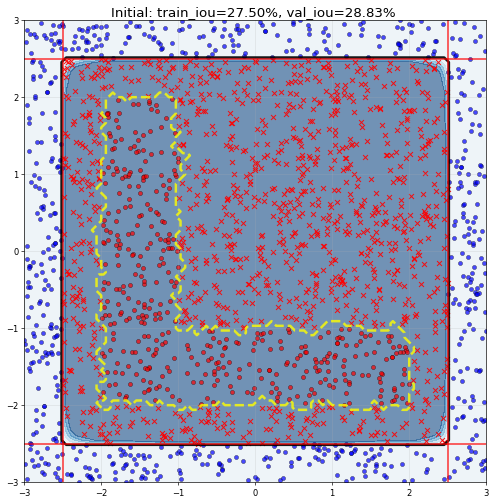

After initial training first block: alpha=0.58664113, K=9.242372, b=-0.33026558
After initial training IoU: train_iou=63.32%, val_iou=63.40%
Found FP cluster with 190 points
Estimated: cluster center(x, y) = (0.19, 0.19), radius = 1.19
New block added: polygon_layer_1 with initial: alpha=-1.0, K=10.0, b=0.0
After training ONLY last added block: polygon_layer_1
Unfreezing & training ALL layers after added block: polygon_layer_1
After block polygon_layer_1 added and trained: train_iou=94.88%, val_IoU = 91.26% (-63.40% = +27.86%)
polygon_layer_0: alpha=0.9037073, K=9.5122175, b=-0.46434897
polygon_layer_1: alpha=-1.2718669, K=10.193636, b=0.32633984
------------------------------------------------------------

No significant clusters found (CLUSTER_MIN_SAMPLES=8)  → stop adding layers
------------------------------------------------------------

Final tunning of all layers...
FINAL: train_IoU = 97.30%, val_IoU = 92.31% 
------------------------------------------------------------
polygon_

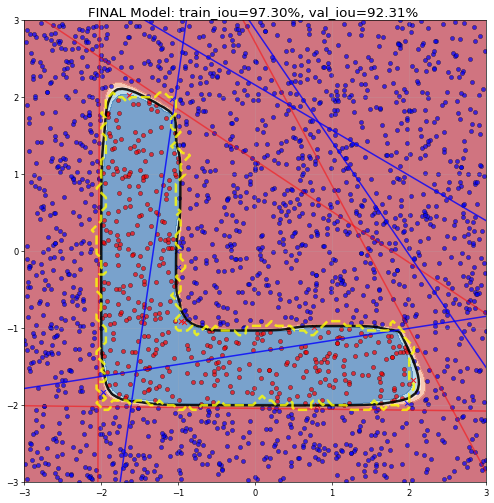

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ xy (InputLayer)     │ (None, 2)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 1)         │          0 │ xy[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ polygon_layer_0     │ (None, 1)         │         15 │ xy[0][0],         │
│ (PolygonLayer)      │                   │            │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ polygon_layer_1     │ (None, 1)         │         15 │ xy[0][0],         │
│ (PolygonLayer)      │                   │            │ polygon_layer_0[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out (Activation)    │ (None, 1)         │          0 │ polygon_layer_1[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 92 (372.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62 (252.00 B)

None
Final validation IoU for L-shape covered by 2 x 4-sided blocks: 92.31%


In [25]:
# L-shape 
random_seed = 42
n_samples = 3000
shape_name = 'L-shape'
corners = [(-2, -2), (2, -2), (2, -1), (-1, -1), (-1, 2), (-2, 2)]
n_sides = 4 # quadrilateral blocks
max_blocks = 3

X, y = generate_polygon_data(corners=corners, n_samples=n_samples, random_seed=random_seed)
print(f"Generated {len(X)} points for {shape_name}\n")
model, val_iou, nb_blocks = run_model_incremental(shape_name, X, y, max_blocks=max_blocks, n_sides=n_sides, random_seed=random_seed)

print(model.summary())
print(f"Final validation IoU for {shape_name} covered by {nb_blocks} x {n_sides}-sided blocks: {val_iou:.2%}")


### 10.2 L-Shape covered by triangles

In [ ]:
# L-shape (by triangles)
random_seed = 42
n_samples = 3000
shape_name = 'L-shape'
corners = [(-2, -2), (2, -2), (2, -1), (-1, -1), (-1, 2), (-2, 2)]
n_sides = 3 # triangle blocks
max_blocks = 3

X, y = generate_polygon_data(corners=corners, n_samples=n_samples, random_seed=random_seed)
print(f"Generated {len(X)} points for {shape_name}\n")
model, val_iou, nb_blocks = run_model_incremental(shape_name, X, y, max_blocks=max_blocks, n_sides=n_sides, random_seed=random_seed)

print(model.summary())
print(f"Final validation IoU for {shape_name} covered by {nb_blocks} x {n_sides}-sided blocks: {val_iou:.2%}")


### 10.3 S-Shape by quadrilaterals

In [ ]:
# S-Shape standard
random_seed = 42
n_samples = 3000
shape_name = 'S-shape'
corners = [
    (-2.0, -2.5),   # Start
    (2.0, -2.5),    # 4 right
    (2.0, 0.5),     # 2 up
    (-1.0, 0.5),    # 3.5 left
    (-1.0, 1.5),    # 1 up
    (2.0, 1.5),     # 3.5 right
    (2.0, 2.5),     # 0.5 up
    (-2.0, 2.5),    # 4 left
    (-2.0, -0.5),    # 2 down
    (1.0, -0.5),     # 3.5 right
    (1.0, -1.5),    # 1 down
    (-2.0, -1.5),   # 3.5 left
]
n_sides = 4 # quadrilateral blocks
max_blocks = 5

X, y = generate_polygon_data(corners=corners, n_samples=n_samples, random_seed=random_seed)
print(f"Generated {len(X)} points for {shape_name}\n")
model, val_iou, nb_blocks = run_model_incremental(shape_name, X, y, max_blocks=max_blocks, n_sides=n_sides, random_seed=random_seed)

print(model.summary())
print(f"Final validation IoU for {shape_name} covered by {nb_blocks} of {n_sides}-sides blocks: {val_iou:.2%}")


### 10.4 S-Shape _rotated_ by quadrilaterals

In [13]:
# S-Shape rotated
random_seed = 42
n_samples = 3000
shape_name = 'S-shape'
corners = [
    (-2.0, -2.5),   # Start
    (2.0, -2.5),    # 4 right
    (2.0, 0.5),     # 2 up
    (-1.0, 0.5),    # 3.5 left
    (-1.0, 1.5),    # 1 up
    (2.0, 1.5),     # 3.5 right
    (2.0, 2.5),     # 0.5 up
    (-2.0, 2.5),    # 4 left
    (-2.0, -0.5),    # 2 down
    (1.0, -0.5),     # 3.5 right
    (1.0, -1.5),    # 1 down
    (-2.0, -1.5),   # 3.5 left
]
n_sides = 4 # quadrilateral blocks
max_blocks = 5

# convert s_shape_corners to numpy then rotate 45 degrees and stretch it by 0.8 then reconvert to list
s_shape_corners_np = np.array(corners)
theta = np.radians(45)  # rotate 45 degrees
rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                            [np.sin(theta), np.cos(theta)]])
s_shape_corners_rotated_np = s_shape_corners_np.dot(rotation_matrix)
s_shape_corners_stretched_np = s_shape_corners_rotated_np * 0.8  # stretch by 0.8 
s_shape_corners = s_shape_corners_stretched_np.tolist()

X, y = generate_polygon_data(corners=s_shape_corners, n_samples=n_samples, random_seed=random_seed)
print(f"Generated {len(X)} points for {shape_name}\n")
model, val_iou, nb_blocks = run_model_incremental(shape_name, X, y, max_blocks=max_blocks, n_sides=n_sides, random_seed=random_seed)

print(model.summary())
print(f"Final validation IoU for {shape_name} covered by {nb_blocks} x {n_sides}-sided blocks: {val_iou:.2%}")


Random seed set to: 42
Generated 3000 points for S-shape

Random seed set to: 42
RUNNING Shape: S-SHAPE with Incremental Blocks
Polygon sides per block: 4
Max blocks: 5
Inside points: 715.0/3000 (23.8%)
Splitting data. Building model. Initializing model weights. ✓ Model initialization checked! (origin prediction = 1.0000)
Initial validation IoU: 34.53%
✓ Model initialization checked! (origin prediction = 1.0000)
Initial validation IoU: 34.53%
Fraction predicted positive: 68.22%
Fraction predicted positive: 68.22%
After initial training first block: alpha=0.3786241, K=8.707818, b=-0.28423995
After initial training IoU: train_iou=46.54%, val_iou=54.79%
After initial training first block: alpha=0.3786241, K=8.707818, b=-0.28423995
After initial training IoU: train_iou=46.54%, val_iou=54.79%
Found FP cluster with 118 points
Estimated: cluster center(x, y) = (0.65, 0.37), radius = 0.94
New block added: polygon_layer_1 with initial: alpha=-1.0, K=10.0, b=0.0
Found FP cluster with 118 points


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ xy (InputLayer)     │ (None, 2)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ xy[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ polygon_layer_0     │ (None, 1)         │         15 │ xy[0][0],         │
│ (PolygonLayer)      │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ polygon_layer_1     │ (None, 1)         │         15 │ xy[0][0],         │
│ (PolygonLayer)      │                   │            │ polygon_layer_0[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ polygon_layer_2     │ (None, 1)         │         15 │ xy[0][0],         │
│ (PolygonLayer)      │                   │            │ polygon_layer_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ polygon_layer_3     │ (None, 1)         │         15 │ xy[0][0],         │
│ (PolygonLayer)      │                   │            │ polygon_layer_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out (Activation)    │ (None, 1)         │          0 │ polygon_layer_3[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 182 (732.00 B)

 Trainable params: 60 (240.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 122 (492.00 B)

None
Final validation IoU for S-shape covered by 4 x 4-sided blocks: 90.50%


### 10.5 Triangle with hole by quadrilaterals

In [14]:
# Holed-triangle
random_seed = 42
n_samples = 3000
shape_name = 'holed-triangle'
n_sides = 4 # quadrilateral blocks
max_blocks = 3
custom_triangle = [(-2.5, 2.2), (-1.0, -2.3), (2.5, 0.4)]

X, y = generate_polygon_data(corners=custom_triangle, n_samples=n_samples, random_seed=random_seed)
x_ix_inner = np.where(((X[:, 0])**2 + (X[:, 1])**2 < 0.7))
y[x_ix_inner] = 0  # make points inside circle as outside the triangle

print(f"Generated {len(X)} points for {shape_name}\n")
model, val_iou, nb_blocks = run_model_incremental(shape_name, X, y, max_blocks=max_blocks, n_sides=n_sides, random_seed=random_seed)

print(model.summary())
print(f"Final validation IoU for {shape_name} covered by {nb_blocks} x {n_sides}-sided blocks: {val_iou:.2%}")

Random seed set to: 42
Generated 3000 points for holed-triangle

Random seed set to: 42
RUNNING Shape: HOLED-TRIANGLE with Incremental Blocks
Polygon sides per block: 4
Max blocks: 3
Inside points: 655.0/3000 (21.8%)
Splitting data. Building model. Initializing model weights. ✓ Model initialization checked! (origin prediction = 1.0000)
Initial validation IoU: 29.48%
Fraction predicted positive: 68.22%
After initial training first block: alpha=1.371639, K=9.811118, b=-0.12980764
After initial training IoU: train_iou=75.74%, val_iou=77.73%
Found FP cluster with 126 points
Estimated: cluster center(x, y) = (0.01, -0.01), radius = 0.79
New block added: polygon_layer_1 with initial: alpha=-1.0, K=10.0, b=0.0
After training ONLY last added block: polygon_layer_1
Unfreezing & training ALL layers after added block: polygon_layer_1
After block polygon_layer_1 added and trained: train_iou=93.43%, val_IoU = 92.63% (-77.73% = +14.90%)
polygon_layer_0: alpha=1.546898, K=9.978045, b=-0.17523181
poly

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ xy (InputLayer)     │ (None, 2)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1)         │          0 │ xy[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ polygon_layer_0     │ (None, 1)         │         15 │ xy[0][0],         │
│ (PolygonLayer)      │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ polygon_layer_1     │ (None, 1)         │         15 │ xy[0][0],         │
│ (PolygonLayer)      │                   │            │ polygon_layer_0[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ polygon_layer_2     │ (None, 1)         │         15 │ xy[0][0],         │
│ (PolygonLayer)      │                   │            │ polygon_layer_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out (Activation)    │ (None, 1)         │          0 │ polygon_layer_2[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 137 (552.00 B)

 Trainable params: 45 (180.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 92 (372.00 B)

None
Final validation IoU for holed-triangle covered by 3 x 4-sided blocks: 94.65%


### 10.6 Eight-figure shape by quadrilaterals

In [ ]:
# Eight-figure-shape 
random_seed = 42
n_samples = 4000
shape_name = 'eight-shape'
n_sides = 4 # quadrilateral blocks
max_blocks = 5

X, y = generate_eight_shape_data_normalized(n_samples=n_samples, random_seed=random_seed)
X = X * 6.0 - 3 # scale it
print(f"Generated {len(X)} points for {shape_name}\n")
model, val_iou, nb_blocks = run_model_incremental(shape_name, X, y, max_blocks=max_blocks, n_sides=n_sides, random_seed=random_seed)

print(model.summary())
print(f"Final validation IoU for {shape_name} covered by {nb_blocks} x {n_sides}-sided blocks: {val_iou:.2%}")

### 10.7 Eight-figure shape by triangles

In [ ]:
# Eight-figure-shape 
random_seed = 42
n_samples = 4000
shape_name = 'eight-shape'
n_sides = 3 # triangular blocks
max_blocks = 7

X, y = generate_eight_shape_data_normalized(n_samples=n_samples, random_seed=random_seed)
X = X * 6.0 - 3 # scale it
print(f"Generated {len(X)} points for {shape_name}\n")
model, val_iou, nb_blocks = run_model_incremental(shape_name, X, y, max_blocks=max_blocks, n_sides=n_sides, random_seed=random_seed)

print(model.summary())
print(f"Final validation IoU for {shape_name} covered by {nb_blocks} x {n_sides}-sided blocks: {val_iou:.2%}")

### 10.8 Eight-figure shape by pentagons

In [ ]:

# Eight-figure-shape 
random_seed = 42
n_samples = 4000
shape_name = 'eight-shape'
n_sides = 5 # pentagon blocks
max_blocks = 5

X, y = generate_eight_shape_data_normalized(n_samples=n_samples, random_seed=random_seed)
X = X * 6.0 - 3 # scale it
print(f"Generated {len(X)} points for {shape_name}\n")
model, val_iou, nb_blocks = run_model_incremental(shape_name, X, y, max_blocks=max_blocks, n_sides=n_sides, random_seed=random_seed)

print(model.summary())
print(f"Final validation IoU for {shape_name} covered by {nb_blocks} x {n_sides}-sided blocks: {val_iou:.2%}")


### 10.9 5-points star shape ⭐ by triangles

In [15]:
# 5-star shape
random_seed = 42
n_samples = 5000
shape_name = '5-star-shape'
n_sides = 3 # triangle blocks
max_blocks = 7

X, y = generate_n_star_data(n_corners=5, n_samples=n_samples, random_seed=random_seed)
print(f"Generated {len(X)} points for {shape_name}\n")
model, val_iou, nb_blocks = run_model_incremental(shape_name, X, y, max_blocks=max_blocks, n_sides=n_sides, random_seed=random_seed)

print(model.summary())
print(f"Final validation IoU for {shape_name} covered by {nb_blocks} x {n_sides}-sided blocks: {val_iou:.2%}")



Random seed set to: 42
Random seed set to: 42
Generated 5000 points for 5-star-shape

Random seed set to: 42
RUNNING Shape: 5-STAR-SHAPE with Incremental Blocks
Polygon sides per block: 3
Max blocks: 7
Inside points: 1283.0/5000 (25.7%)
Splitting data. Building model. Initializing model weights. ✓ Model initialization checked! (origin prediction = 1.0000)
Initial validation IoU: 34.13%
Fraction predicted positive: 75.60%
After initial training first block: alpha=0.22582187, K=8.526685, b=-0.5580346
After initial training IoU: train_iou=69.85%, val_iou=68.66%
Found FN cluster with 107 points
Estimated: cluster center(x, y) = (0.33, 1.57), radius = 0.64
New block added: polygon_layer_1 with initial: alpha=1.0, K=10.0, b=0.0
After training ONLY last added block: polygon_layer_1
Unfreezing & training ALL layers after added block: polygon_layer_1
After block polygon_layer_1 added and trained: train_iou=79.84%, val_IoU = 78.28% (-68.66% = +9.62%)
polygon_layer_0: alpha=0.49442747, K=8.679954

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ xy (InputLayer)     │ (None, 2)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 1)         │          0 │ xy[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ polygon_layer_0     │ (None, 1)         │         12 │ xy[0][0],         │
│ (PolygonLayer)      │                   │            │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ polygon_layer_1     │ (None, 1)         │         12 │ xy[0][0],         │
│ (PolygonLayer)      │                   │            │ polygon_layer_0[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ polygon_layer_2     │ (None, 1)         │         12 │ xy[0][0],         │
│ (PolygonLayer)      │                   │            │ polygon_layer_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ polygon_layer_3     │ (None, 1)         │         12 │ xy[0][0],         │
│ (PolygonLayer)      │                   │            │ polygon_layer_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out (Activation)    │ (None, 1)         │          0 │ polygon_layer_3[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 146 (588.00 B)

 Trainable params: 48 (192.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 98 (396.00 B)

None
Final validation IoU for 5-star-shape covered by 4 x 3-sided blocks: 92.71%


### 10.10 5-points Star ⭐ by pentagons 

In [ ]:
# 5-star shape
random_seed = 42
n_samples = 5000
shape_name = '5-star-shape'
n_sides = 5 # pentagon blocks
max_blocks = 7

X, y = generate_n_star_data(n_corners=5, n_samples=n_samples, random_seed=random_seed)
print(f"Generated {len(X)} points for {shape_name}\n")
model, val_iou, nb_blocks = run_model_incremental(shape_name, X, y, max_blocks=max_blocks, n_sides=n_sides, random_seed=random_seed)

print(model.summary())
print(f"Final validation IoU for {shape_name} covered by {nb_blocks} x {n_sides}-sided blocks: {val_iou:.2%}")



### 10.11 Donut by pentagons

In [38]:
# donut shape
random_seed = 42
n_samples = 3000
shape_name = 'donut'
n_sides = 5 # pentagon blocks
max_blocks = 3

X, y = generate_donut_data(n_samples=n_samples, random_seed=random_seed)
print(f"Generated {len(X)} points for {shape_name}\n")
model, val_iou, nb_blocks = run_model_incremental(shape_name, X, y, max_blocks=max_blocks, n_sides=n_sides, random_seed=random_seed)

print(model.summary())
print(f"Final validation IoU for {shape_name} covered by {nb_blocks} x {n_sides}-sided blocks: {val_iou:.2%}")



Random seed set to: 42
Generated 3000 points for donut

Random seed set to: 42
RUNNING Shape: DONUT with Incremental Blocks
Polygon sides per block: 5
Max blocks: 3
Inside points: 1253.0/3000 (41.8%)
Splitting data. Building model. Initializing model weights. ✓ Model initialization checked! (origin prediction = 1.0000)
Initial validation IoU: 68.67%
Fraction predicted positive: 61.00%
After initial training first block: alpha=0.4194799, K=8.676917, b=-0.4189577
After initial training IoU: train_iou=76.40%, val_iou=79.69%
Found FP cluster with 187 points
Estimated: cluster center(x, y) = (0.01, -0.00), radius = 0.98
New block added: polygon_layer_1 with initial: alpha=-1.0, K=10.0, b=0.0
After training ONLY last added block: polygon_layer_1
Unfreezing & training ALL layers after added block: polygon_layer_1
After block polygon_layer_1 added and trained: train_iou=96.12%, val_IoU = 96.87% (-79.69% = +17.18%)
polygon_layer_0: alpha=0.79348755, K=8.830905, b=-1.1850145
polygon_layer_1: alp

Model: "functional_50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ xy (InputLayer)     │ (None, 2)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_13 (Lambda)  │ (None, 1)         │          0 │ xy[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ polygon_layer_0     │ (None, 1)         │         18 │ xy[0][0],         │
│ (PolygonLayer)      │                   │            │ lambda_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ polygon_layer_1     │ (None, 1)         │         18 │ xy[0][0],         │
│ (PolygonLayer)      │                   │            │ polygon_layer_0[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out (Activation)    │ (None, 1)         │          0 │ polygon_layer_1[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 110 (444.00 B)

 Trainable params: 36 (144.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 74 (300.00 B)

None
Final validation IoU for donut covered by 2 x 5-sided blocks: 95.29%


## 11. Conclusion & What’s Next

This notebook demonstrated how the **PolygonLayer** can be used for **non-convex shape classification** through an incremental, interpretable approach.

Key Takeaways:
- 🧩 Incremental blocks progressively refine the decision boundary.
- ⚙️ Each block adds or subtracts regions via its α parameter.
- 🔍 DBSCAN guides where new blocks should focus.
- 📐 Geometric initialization provides stable, balanced starting weights.
- 🎨 Visual tools make the model’s logic transparent and easy to interpret.

---
## 🔗 See also

👉 *Next*: [Non-convex Shape Classification with Soft Ellipse RBFs](https://github.com/Dani-Luk/kaggle-soft-ellipse-rbf)  


👈 *Previous*: [Convex Polygon Shape Classification with Custom Activations](<https://github.com/Dani-Luk/kaggle-wrapping-convex-shape-classifier/tree/main>)